# 03 Paired Family Structure

Once the thesis established that hybrid and paired domains are far apart, the next question became: is the paired target domain itself homogeneous? The answer is no, and this notebook explains why that matters.

**Questions answered here**
- How different are the paired families from one another?
- What happens when one family is fully unseen during training?
- Why do some families transfer well while others break?


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

def _find_thesis_root():
    cwd = Path.cwd().resolve()
    direct = [cwd, *cwd.parents]
    nested = [candidate / "thesis" for candidate in direct]
    for candidate in [*direct, *nested]:
        if (candidate / "THESIS_BLUEPRINT.md").exists() and (candidate / "src" / "qc_thesis" / "__init__.py").exists():
            return candidate
    raise FileNotFoundError("Could not find thesis root from notebook session")

ROOT = _find_thesis_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from qc_thesis import *

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
apply_thesis_style()

fig_dir, table_dir = notebook_output_dirs("03_paired_family_structure")
domain_bundle = get_domain_shift_bundle()
limitations = get_limitations_bundle()
family_coverage = build_family_coverage_table()


## 1. Family coverage inside the paired domain

The paired benchmark is not just small; it is uneven. Some families contribute many more units or recordings than others, which already creates a robustness challenge before any model is trained.


In [2]:
display(family_coverage)
save_table(family_coverage, table_dir, "paired_family_coverage")


,study_set,rows,recordings,sorters,labeled_rows
0,PAIRED_ENGLISH,3151,15,7,71
1,PAIRED_MEA64C_YGER,2997,4,9,36
2,PAIRED_KAMPFF,1743,4,8,35
3,PAIRED_BOYDEN,907,4,8,43
4,PAIRED_CRCNS_HC1,184,4,8,22


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/thesis/tables/03_paired_family_structure/paired_family_coverage.csv')

## 2. Geometry of the paired families

The paired-only PCA shows whether families occupy distinct regions or overlap cleanly. The important point is not perfect separation, but visible heterogeneity.


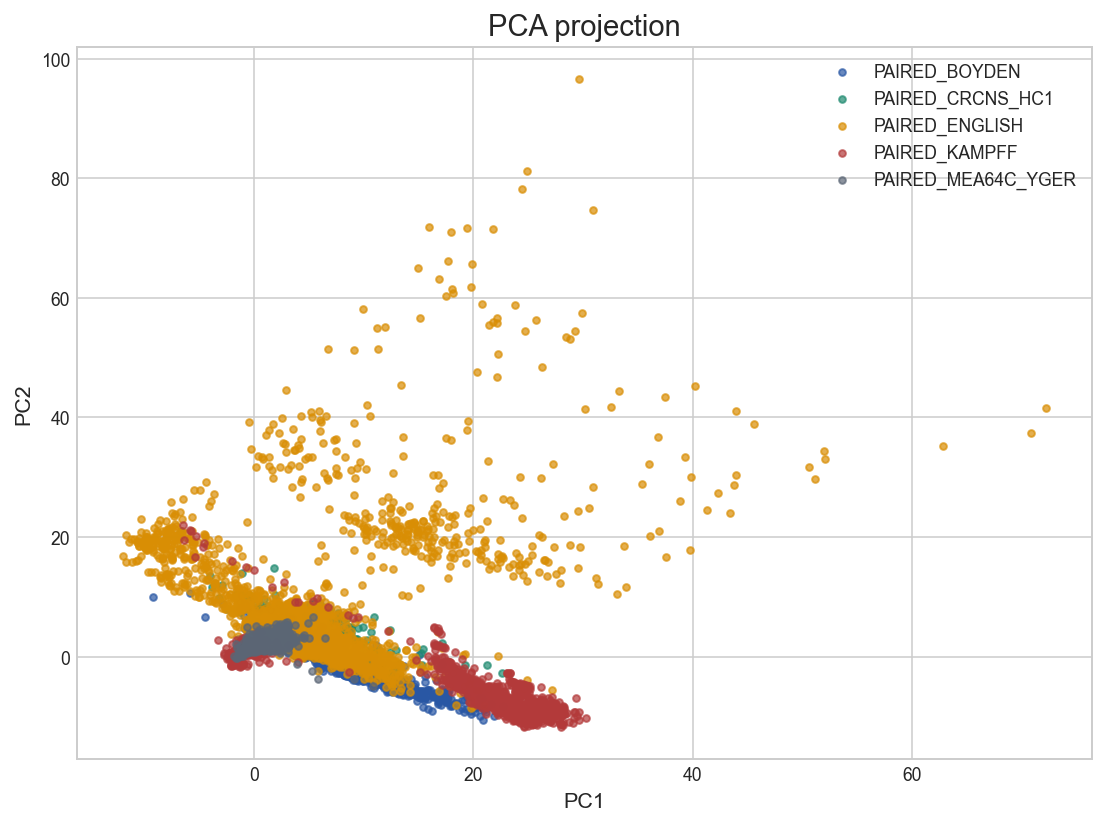

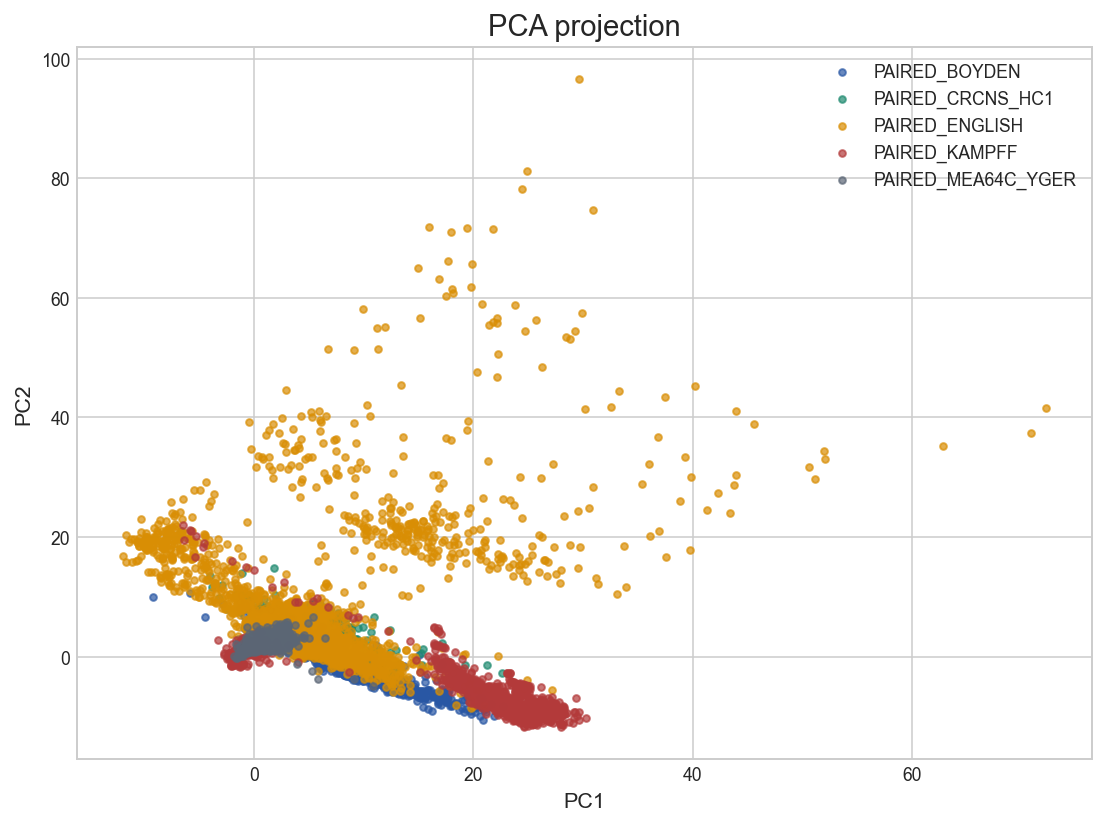

In [3]:
paired_only = domain_bundle.pca_2d[domain_bundle.pca_2d["dataset_type"] == "paired"].copy()
save_table(paired_only, table_dir, "paired_pca_points")
fig, _ = plot_pca_projection(paired_only, color_col="study_set")
save_figure(fig, fig_dir, "paired_family_pca_2d")
fig


## 3. Leave-one-family-out stress test

The main benchmark is still recording-disjoint. But this stress test asks a harsher question: what happens when an entire paired family is unseen? The answer shows which families behave like bridge domains and which behave like island domains.


,variant_id,macro_mae,macro_r2,weighted_mae,weighted_r2,worst_family_r2,best_family_r2
0,reference_anchor_stack_xgboost,0.125455,0.452724,0.131071,0.423981,0.293988,0.546858
1,wf_embed_anchor_stack_xgboost,0.122189,0.438568,0.126716,0.411617,0.148179,0.695184


,held_out_family,variant_id,mae,r2,bias,n_test_rows,n_test_recordings,pseudo_rows
0,PAIRED_BOYDEN,reference_anchor_stack_xgboost,0.074722,0.293988,-0.003118,43,4,193
1,PAIRED_CRCNS_HC1,reference_anchor_stack_xgboost,0.167210,0.538221,-0.064518,22,4,256
2,PAIRED_ENGLISH,reference_anchor_stack_xgboost,0.185688,0.351366,-0.009768,71,13,204
3,PAIRED_KAMPFF,reference_anchor_stack_xgboost,0.131304,0.546858,0.067875,35,4,213
4,PAIRED_MEA64C_YGER,reference_anchor_stack_xgboost,0.068349,0.533186,0.037329,36,4,182
5,PAIRED_BOYDEN,wf_embed_anchor_stack_xgboost,0.075131,0.148179,0.011304,43,4,193
6,PAIRED_CRCNS_HC1,wf_embed_anchor_stack_xgboost,0.178838,0.483317,-0.074358,22,4,256
7,PAIRED_ENGLISH,wf_embed_anchor_stack_xgboost,0.180457,0.362484,0.018255,71,13,204
8,PAIRED_KAMPFF,wf_embed_anchor_stack_xgboost,0.101993,0.695184,0.042196,35,4,213
9,PAIRED_MEA64C_YGER,wf_embed_anchor_stack_xgboost,0.074528,0.503675,0.037297,36,4,182


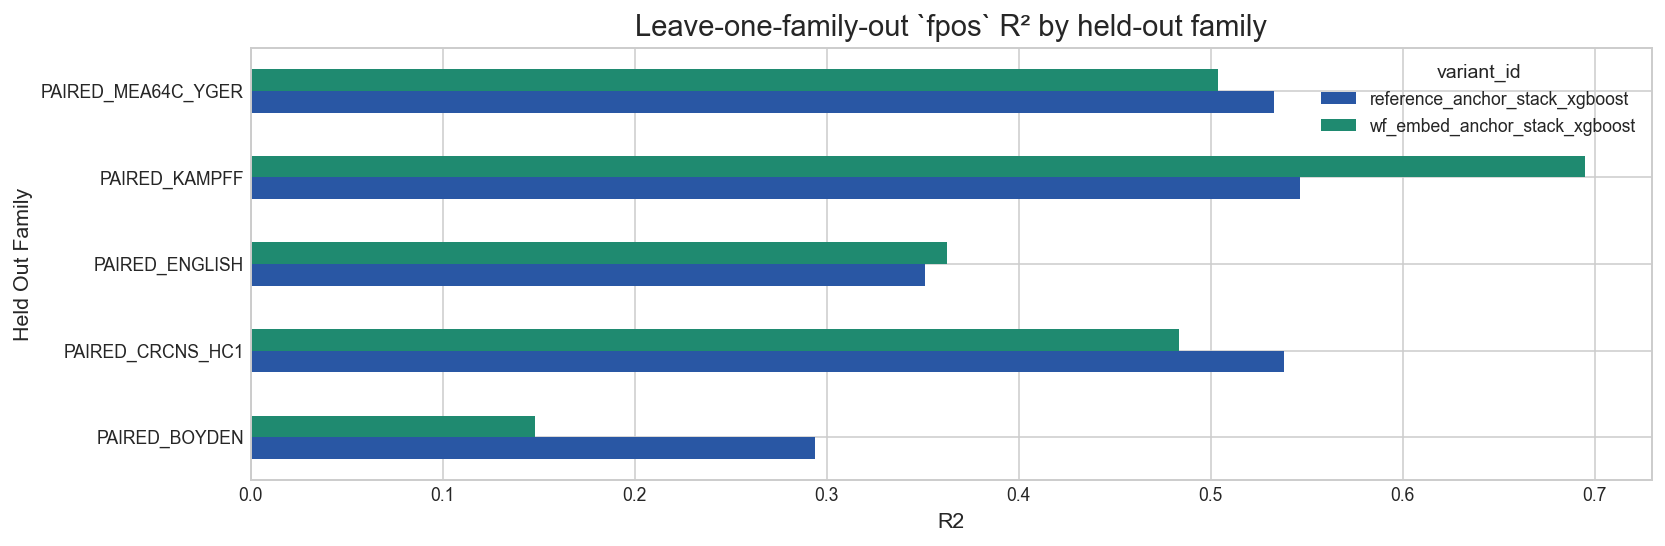

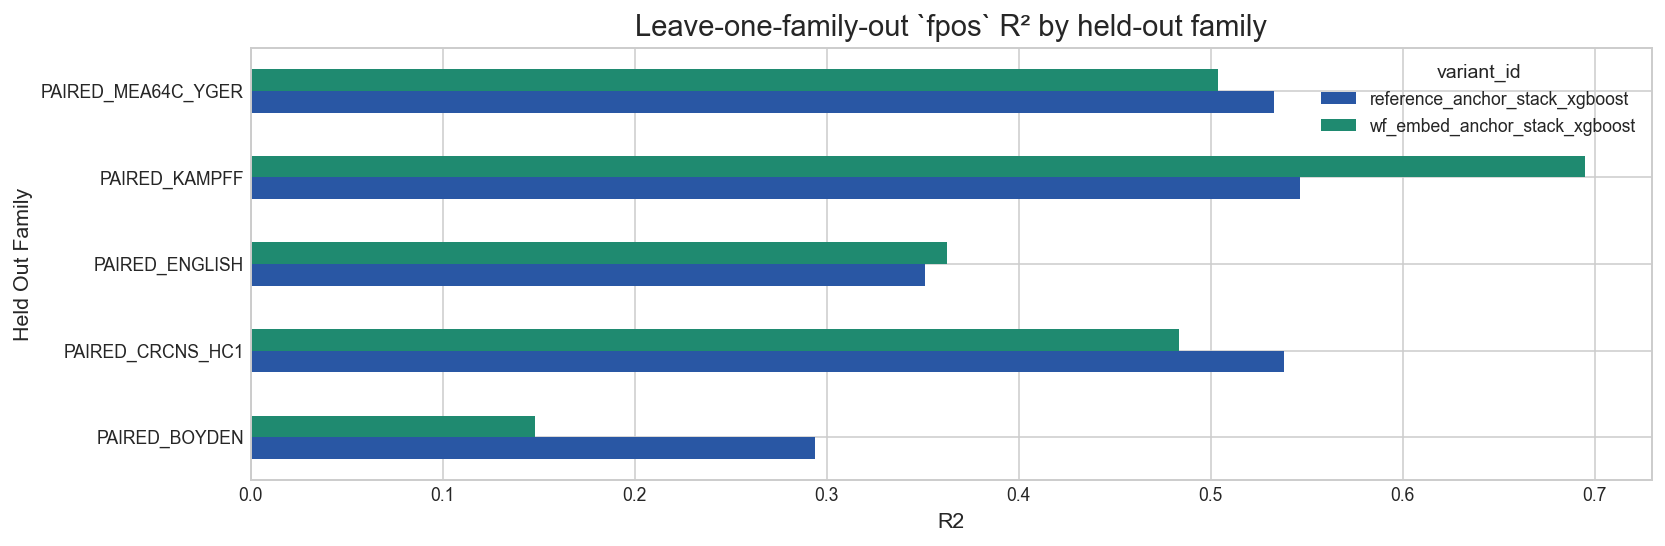

In [4]:
display(limitations.lofo_aggregate)
display(limitations.lofo_family)
save_table(limitations.lofo_aggregate, table_dir, "leave_one_family_aggregate")
save_table(limitations.lofo_family, table_dir, "leave_one_family_by_family")
fig, _, _ = plot_group_metric(limitations.lofo_family, group_col="held_out_family", metric="r2", title="Leave-one-family-out `fpos` R² by held-out family")
save_figure(fig, fig_dir, "leave_one_family_r2_by_family")
fig


## 4. Why some families improve and others crash

The interesting behavior in the leave-one-family-out benchmark is that some held-out families remain strong while others collapse. That happens because each held-out family defines a different transfer problem: some are reconstructible from the remaining families, others are not.


In [5]:
pivot = limitations.lofo_family.pivot_table(index="held_out_family", columns="variant_id", values="r2")
pivot["waveform_minus_reference"] = pivot["wf_embed_anchor_stack_xgboost"] - pivot["reference_anchor_stack_xgboost"]
gap_table = pivot.reset_index().sort_values("waveform_minus_reference")
display(gap_table)
save_table(gap_table, table_dir, "leave_one_family_gap_table")


variant_id,held_out_family,reference_anchor_stack_xgboost,wf_embed_anchor_stack_xgboost,waveform_minus_reference
0,PAIRED_BOYDEN,0.293988,0.148179,-0.145810
1,PAIRED_CRCNS_HC1,0.538221,0.483317,-0.054903
4,PAIRED_MEA64C_YGER,0.533186,0.503675,-0.029510
2,PAIRED_ENGLISH,0.351366,0.362484,0.011118
3,PAIRED_KAMPFF,0.546858,0.695184,0.148325


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/thesis/tables/03_paired_family_structure/leave_one_family_gap_table.csv')

In [6]:
display(Markdown(
    """
## Key takeaways

- The paired domain is not one clean target domain; it is a mixture of families with different transfer behavior.
- Leave-one-family-out is therefore a real robustness test, not just a stricter version of the main benchmark.
- The waveform-enhanced `fpos` winner is not uniformly best under unseen-family transfer, which is why the thesis reports both optimization and robustness protocols.
"""
))



## Key takeaways

- The paired domain is not one clean target domain; it is a mixture of families with different transfer behavior.
- Leave-one-family-out is therefore a real robustness test, not just a stricter version of the main benchmark.
- The waveform-enhanced `fpos` winner is not uniformly best under unseen-family transfer, which is why the thesis reports both optimization and robustness protocols.
